<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_Random_forest(%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D1%87).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [ ]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [ ]:
# Ваш код
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O /content/train.csv
df = pd.read_csv('/content/train.csv')

--2026-04-20 18:10:11--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘/content/train.csv’

/content/train.csv  100%[===================>]  58.89K  --.-KB/s    in 0.008s  

2026-04-20 18:10:11 (7.15 MB/s) - ‘/content/train.csv’ saved [60302/60302]



### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


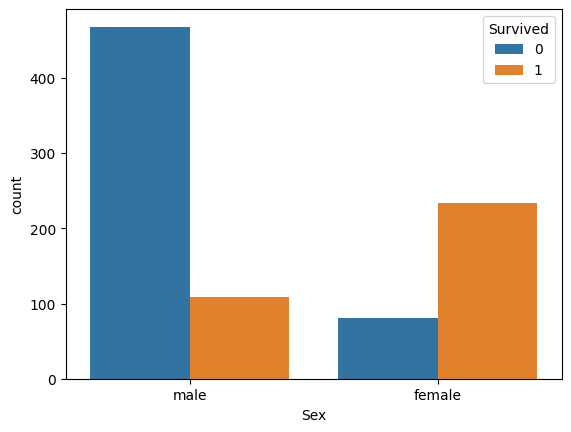

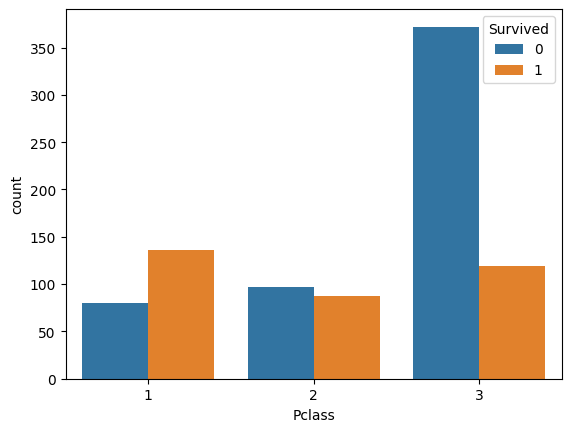

In [ ]:
# Ваш код
df.info()
df.isnull().sum()
df.describe()
df['Survived'].value_counts()

sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

### 4. Сформируем обучающую и тестовую выборки:


In [ ]:
# Ваш код
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y = df['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (712, 6)
X_test: (179, 6)


### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [ ]:
# Ваш код
med_age = X_train['Age'].median()
X_train['Age'] = X_train['Age'].fillna(med_age)
X_test['Age'] = X_test['Age'].fillna(med_age)

X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

X_train['Fare'] = X_train['Fare'].fillna(X_train['Fare'].median())
X_test['Fare'] = X_test['Fare'].fillna(X_train['Fare'].median())

print("Isnull in X_train:\n", X_train.isnull().sum())
print("\nIsnull in X_test:\n", X_test.isnull().sum())

Isnull in X_train:
 Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

Isnull in X_test:
 Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64


### 6. Построение базовой модели:

In [ ]:
# Ваш код
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.804
[[90 15]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [ ]:
# Ваш код
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def eval_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predict')
    plt.ylabel('Fact')
    plt.show()
    print(classification_report(y_true, y_pred))

#### 7.2. Оцените точность модели:

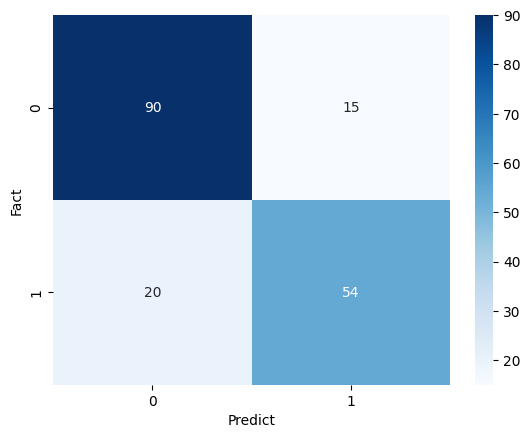

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

Accuracy: 0.8045


In [ ]:
# Ваш код
eval_model(y_test, y_pred)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [ ]:
# Ваш код
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

param_dist = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2', None]}
rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Best params (RandomSearch):", random_search.best_params_)
print("Best accuracy (RandomSearch): {:.4f}".format(random_search.best_score_))

best_rf_random = random_search.best_estimator_

Best params (RandomSearch): {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best accuracy (RandomSearch): 0.8342


#### GridSearchCV

In [ ]:
# Ваш код
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt', 'log2']}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params (GridSearch):", grid_search.best_params_)
print("Best accuracy (GridSearch): {:.4f}".format(grid_search.best_score_))

best_rf_grid = grid_search.best_estimator_

Best params (GridSearch): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best accuracy (GridSearch): 0.8300


### 9. Комплексная оценка точности лучшей модели:

Cross-validation accuracy:
Mean: 0.8300 (+/- 0.0370)


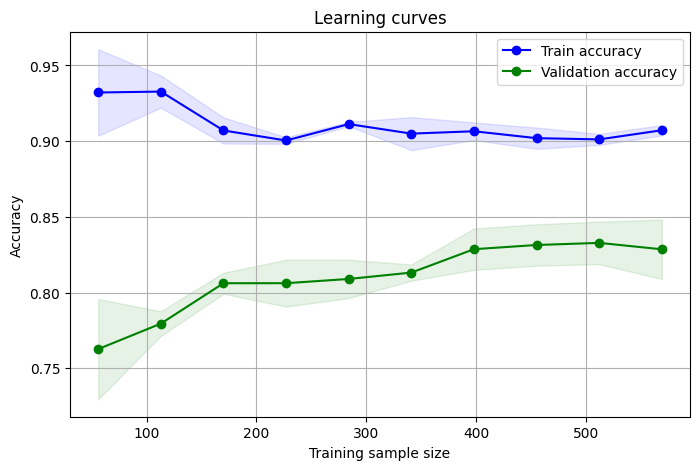

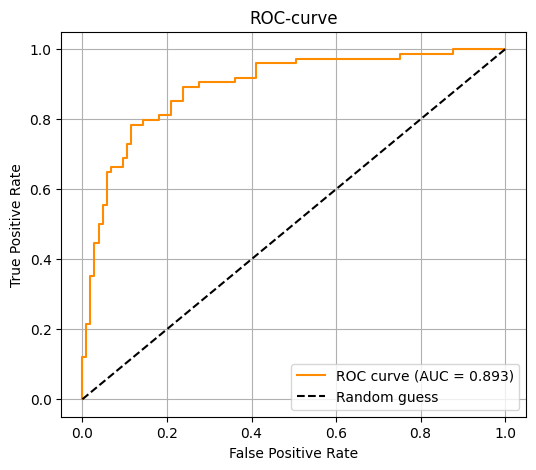

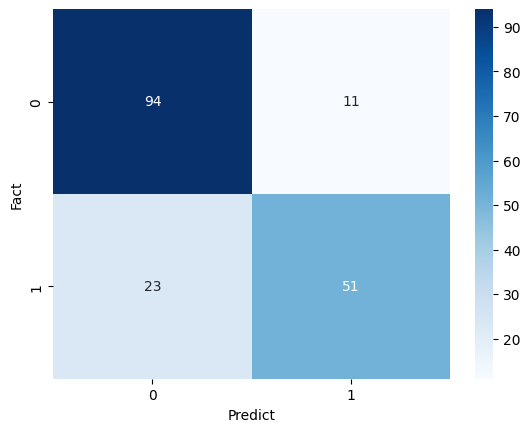

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.82      0.69      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# Ваш код
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import roc_curve, roc_auc_score

best_model = best_rf_grid

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation accuracy:")
print("Mean: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

train_sizes, train_scores, test_scores = learning_curve(best_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Validation accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.xlabel('Training sample size')
plt.ylabel('Accuracy')
plt.title('Learning curves')
plt.legend(loc='best')
plt.grid(True)
plt.show()

y_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

eval_model(y_test, best_model.predict(X_test))

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [ ]:
# Ваш код
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

results = {}

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
results['LogisticRegression'] = acc_lr
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
results['DecisionTree'] = acc_dt
print(f"Decision Tree Accuracy: {acc_dt:.4f}")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
results['KNN'] = acc_knn
print(f"KNN Accuracy: {acc_knn:.4f}")

acc_rf = accuracy_score(y_test, y_pred)
results['RandomForest'] = acc_rf
print(f"Random Forest Accuracy: {acc_rf:.4f}")

acc_best_rf = accuracy_score(y_test, best_rf_grid.predict(X_test))
results['RandomForest_tuned'] = acc_best_rf
print(f"Random Forest) Accuracy: {acc_best_rf:.4f}")

for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:20s}: {acc:.4f}")

Logistic Regression Accuracy: 0.8101
Decision Tree Accuracy: 0.7598
KNN Accuracy: 0.6872
Random Forest Accuracy: 0.8045
Random Forest) Accuracy: 0.8101
LogisticRegression  : 0.8101
RandomForest_tuned  : 0.8101
RandomForest        : 0.8045
DecisionTree        : 0.7598
KNN                 : 0.6872


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [ ]:
# Ваш код
import pandas as pd

def predict_interactive(model):
    input_data = {}

    while True:
        try:
            pclass = int(input("Pclass (1, 2 or 3): "))
            if pclass not in [1, 2, 3]:
                raise ValueError("1, 2, 3")
            input_data['Pclass'] = pclass
            break
        except ValueError as e:
            print(f"Error: {e}. Try again.")

    while True:
        sex = input("Sex ('male' or 'female'): ").strip().lower()
        if sex in ['male', 'female']:
            input_data['Sex'] = 0 if sex == 'male' else 1
            break
        else:
            print("'male' or 'female'")

    while True:
        try:
            age = float(input("Age (0 to 100): "))
            if age < 0 or age > 100:
                raise ValueError("0 to 100")
            input_data['Age'] = age
            break
        except ValueError as e:
            print(f"Error: Try again. {e}")

    while True:
        try:
            sib = int(input("SibSp (0 to 8): "))
            if sib < 0 or sib > 8:
                raise ValueError("0 to 8")
            input_data['SibSp'] = sib
            break
        except ValueError as e:
            print(f"Error: Try again. {e}")

    while True:
        try:
            parch = int(input("Parch (0 to 6): "))
            if parch < 0 or parch > 6:
                raise ValueError("0 to 6")
            input_data['Parch'] = parch
            break
        except ValueError as e:
            print(f"Error: Try again. {e}")

    while True:
        try:
            fare = float(input("Fare (0 to 600): "))
            if fare < 0 or fare > 600:
                raise ValueError("0 to 600")
            input_data['Fare'] = fare
            break
        except ValueError as e:
            print(f"Error: Try again. {e}")

    input_df = pd.DataFrame([input_data])

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0] if hasattr(model, 'predict_proba') else None

    if pred == 1:
        print("SURVIVED")
    else:
        print("DIED")
    if proba is not None:
        print(f"Probability of survival: {proba[1]:.2%}")



predict_interactive(best_rf_grid)

Pclass (1, 2 or 3): 1
Sex ('male' or 'female'): male
Age (0 to 100): 34
SibSp (0 to 8): 3
Parch (0 to 6): 2
Fare (0 to 600): 480
DIED
Probability of survival: 43.33%


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [ ]:
# Ваш код
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


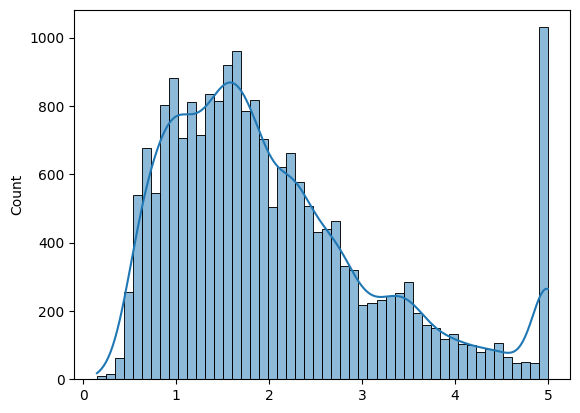

In [ ]:
print(X.isnull().sum())

X.describe()

sns.histplot(y, bins=50, kde=True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
base_rf.fit(X_train, y_train)

y_pred_base = base_rf.predict(X_test)
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"R2: {base_r2:.4f}")
print(f"RMSE: {base_rmse:.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_base):.4f}")

R2: 0.8051
RMSE: 0.5053
MAE: 0.3275


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import numpy as np

n_samples = 10000
if X_train.shape[0] > n_samples:
    idx = np.random.choice(X_train.shape[0], n_samples, replace=False)
    X_train_sub = X_train.iloc[idx]
    y_train_sub = y_train[idx]
else:
    X_train_sub = X_train
    y_train_sub = y_train

param_dist = {'n_estimators': randint(50, 200), 'max_depth': [None, 10, 20, 30], 'min_samples_split': randint(2, 10), 'min_samples_leaf': randint(1, 5), 'max_features': ['sqrt', 'log2', None]}
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1), param_distributions=param_dist, n_iter=20, cv=3, scoring='r2', verbose=1, random_state=42, n_jobs=-1)

random_search.fit(X_train_sub, y_train_sub)

print(random_search.best_params_)
print(f"Best R2: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 103}
Best R2: 0.7952


In [ ]:
best_params = random_search.best_params_
param_grid = {'n_estimators': [max(50, best_params['n_estimators'] - 20), best_params['n_estimators'], best_params['n_estimators'] + 20], 'max_depth': [best_params['max_depth']], 'min_samples_split': [max(2, best_params['min_samples_split'] - 1), best_params['min_samples_split'], best_params['min_samples_split'] + 1], 'min_samples_leaf': [max(1, best_params['min_samples_leaf'] - 1), best_params['min_samples_leaf'], best_params['min_samples_leaf'] + 1], 'max_features': [best_params['max_features']]}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1), param_grid=param_grid, cv=3, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params (GridSearchCV):")
print(grid_search.best_params_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params (GridSearchCV):
{'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 83}


In [ ]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
best_r2 = r2_score(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_mae = mean_absolute_error(y_test, y_pred_best)

print(f"R2: {best_r2:.4f}")
print(f"RMSE: {best_rmse:.4f}")
print(f"MAE: {best_mae:.4f}")

print(f"R2 improved from {base_r2:.4f} to {best_r2:.4f}")
print(f"RMSE improved from {base_rmse:.4f} to {best_rmse:.4f}")

R2: 0.8113
RMSE: 0.4973
MAE: 0.3266
R2 improved from 0.8051 to 0.8113
RMSE improved from 0.5053 to 0.4973


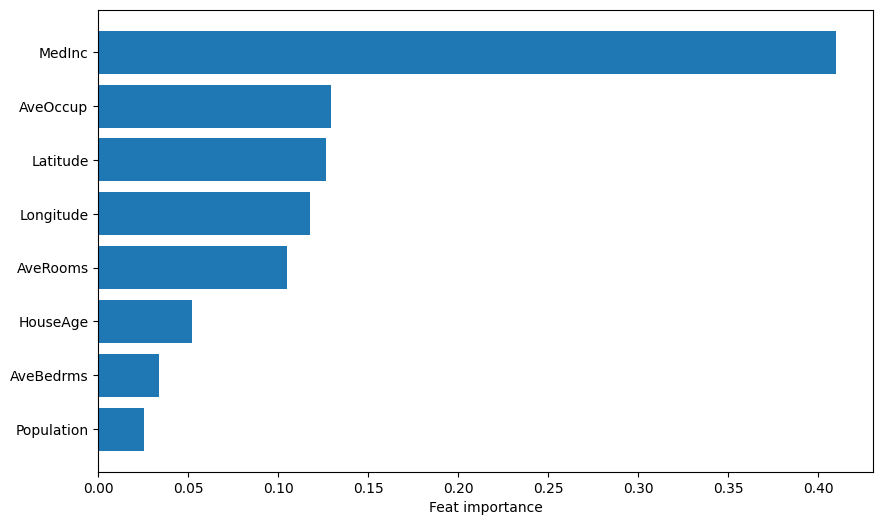

In [ ]:
feature_importance = best_model.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feat importance')
plt.gca().invert_yaxis()
plt.show()

## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [1]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [2]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [3]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


Cons import:
A: 0.0323
B: 0.0288
C: 0.9039
D: 0.0350

Most import: C


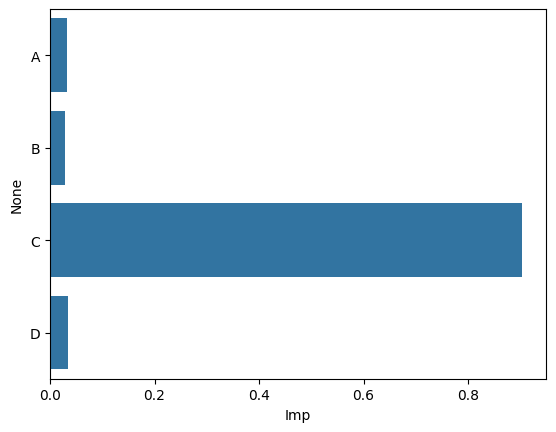

In [4]:
# Ваш код
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

X = data[['A', 'B', 'C', 'D']]
y = data['Spoiled']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

imp = rf.feature_importances_
feat_names = X.columns
print("Cons import:")
for name, val in zip(feat_names, imp):
    print(f"{name}: {val:.4f}")

most_important = feat_names[imp.argmax()]
print(f"\nMost import: {most_important}")

sns.barplot(x=imp, y=feat_names)
plt.xlabel('Imp')
plt.show()